# Avaliação de Métodos Numéricos para Busca de Raízes

**Objetivo:** implementar gradiente descendente para busca de raízes, inclusive com múltiplas inicializações, e comparar seu desempenho com bisseção, falsa posição e ponto fixo nas seis funções da questão 4. Newton-Raphson e secante são incluídos como referências auxiliares.

### Critérios da atividade
- Número máximo de iterações: **200**.
- Tolerância: **\(10^{-10}\)**, aplicada de forma consistente como o tamanho do passo entre iteradas consecutivas, \(|x_{k+1}-x_k|\le 10^{-10}\).
- Bisseção e falsa posição usam o intervalo fornecido.
- **Para todos os métodos abertos — incluindo o gradiente descendente — usa-se o limite direito do intervalo como estimativa inicial**, exatamente como pedido no enunciado ("escolha um dos limites do intervalo"). A secante recebe uma segunda estimativa interna, próxima do limite.
- A comparação registra raiz, erro absoluto em relação à referência, iterações, convergência e tempo.

> Em uma raiz múltipla, um resíduo pequeno não implica necessariamente erro pequeno em \(x\). Por isso, resíduo e erro absoluto são apresentados separadamente, enquanto o critério de parada adotado é baseado em \(\Delta x\).

## 1. Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import scipy.optimize as opt
import timeit
import matplotlib.pyplot as plt

np.set_printoptions(precision=12, suppress=True)
print("SciPy:", __import__("scipy").__version__)

SciPy: 1.17.1


## 2. Implementação dos métodos

O critério principal de convergência usado na implementação é

\[
|x_{k+1}-x_k| \le 10^{-10}.
\]

O resíduo \(|f(x)|\) também é registrado para avaliar a qualidade da aproximação da raiz. Isso é importante para funções com raízes múltiplas, nas quais um passo pequeno pode ocorrer antes que o erro em \(x\) seja suficientemente pequeno.


In [2]:
TOL = 1e-10
MAX_ITER = 200


def _resultado(root, converged, iterations, function_calls=0,
               derivative_calls=0, residual=np.nan, **extra):
    return {
        "root": float(root),
        "converged": bool(converged),
        "iterations": int(iterations),
        "function_calls": function_calls,
        "derivative_calls": derivative_calls,
        "residual": float(residual) if np.isfinite(residual) else np.nan,
        **extra,
    }


def gradient_descent_root(
    f, fprime, x0, lr=0.01, objective="quadratic", tol=TOL,
    max_iter=MAX_ITER, adaptive=True, max_step=1.0, min_lr=1e-14
):
    """Encontra uma raiz minimizando uma função objetivo não negativa."""
    x = float(x0)
    cur_lr = float(lr)
    f_calls = 0
    fp_calls = 0
    backtracks_total = 0

    def objective_value(fx):
        if objective == "quadratic":
            return 0.5 * fx**2
        if objective == "log_quadratic":
            return np.log1p(fx**2)
        raise ValueError("objective deve ser 'quadratic' ou 'log_quadratic'")

    def objective_gradient(fx, dfx):
        if objective == "quadratic":
            return fx * dfx
        return 2.0 * fx * dfx / (1.0 + fx**2)

    for iteration in range(1, max_iter + 1):
        fx = float(f(x)); f_calls += 1
        dfx = float(fprime(x)); fp_calls += 1
        if not np.isfinite(fx) or not np.isfinite(dfx):
            return _resultado(x, False, iteration - 1, f_calls, fp_calls, np.nan,
                              backtracks=backtracks_total, objective=objective)

        current = objective_value(fx)
        gradient = objective_gradient(fx, dfx)
        step = cur_lr * gradient
        if max_step is not None:
            step = np.clip(step, -max_step, max_step)
        x_new = x - step

        if adaptive:
            new_value = objective_value(float(f(x_new))); f_calls += 1
            backtracks = 0
            while ((not np.isfinite(new_value) or new_value > current)
                   and cur_lr > min_lr and backtracks < 50):
                cur_lr *= 0.5
                step = cur_lr * gradient
                if max_step is not None:
                    step = np.clip(step, -max_step, max_step)
                x_new = x - step
                new_value = objective_value(float(f(x_new))); f_calls += 1
                backtracks += 1
                backtracks_total += 1

        if not np.isfinite(x_new) or abs(x_new) > 1e12:
            return _resultado(x_new, False, iteration, f_calls, fp_calls, np.nan,
                              backtracks=backtracks_total, objective=objective)

        fx_new = float(f(x_new)); f_calls += 1
        if abs(x_new - x) <= tol:
            return _resultado(x_new, True, iteration, f_calls, fp_calls, abs(fx_new),
                              backtracks=backtracks_total, objective=objective)
        x = x_new

    return _resultado(x, False, max_iter, f_calls, fp_calls, abs(float(f(x))),
                      backtracks=backtracks_total, objective=objective)


def gradient_descent_multistart(f, fprime, interval, starts=21, **kwargs):
    """Executa GD a partir de vários pontos e remove raízes duplicadas."""
    a, b = interval
    roots = []
    results = []
    for x0 in np.linspace(a, b, starts):
        result = gradient_descent_root(f, fprime, x0, **kwargs)
        results.append(result)
        if result["converged"] and all(abs(result["root"] - root) > 1e-7 for root in roots):
            roots.append(result["root"])
    return {"roots": sorted(roots), "results": results}


def scipy_bisection_root(f, a, b, tol=TOL, max_iter=MAX_ITER):
    try:
        root, result = opt.bisect(
            f, a, b, xtol=tol, rtol=4*np.finfo(float).eps,
            maxiter=max_iter, full_output=True, disp=False
        )
        return _resultado(root, result.converged, result.iterations,
                          result.function_calls, residual=abs(float(f(root))))
    except (ValueError, RuntimeError):
        return _resultado(np.nan, False, max_iter, residual=np.nan)


def false_position_root(f, a, b, tol=TOL, max_iter=MAX_ITER):
    fa, fb = float(f(a)), float(f(b))
    calls = 2
    if fa == 0:
        return _resultado(a, True, 0, calls, residual=0.0)
    if fb == 0 or fa * fb > 0:
        return _resultado(b if fb == 0 else np.nan, fb == 0, 0, calls,
                          residual=abs(fb) if fb == 0 else np.nan)

    c_prev = a
    for iteration in range(1, max_iter + 1):
        c = (a * fb - b * fa) / (fb - fa)
        fc = float(f(c)); calls += 1
        if abs(c - c_prev) <= tol:
            return _resultado(c, True, iteration, calls, residual=abs(fc))
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
        c_prev = c
    return _resultado(c, False, max_iter, calls, residual=abs(float(f(c))))


def fixed_point_root(f, g, x0, tol=TOL, max_iter=MAX_ITER):
    x = float(x0)
    calls = 0
    for iteration in range(1, max_iter + 1):
        x_new = float(g(x)); calls += 1
        if not np.isfinite(x_new) or abs(x_new) > 1e12:
            return _resultado(x_new, False, iteration, calls, residual=np.nan)
        residual = abs(float(f(x_new))); calls += 1
        if abs(x_new - x) <= tol:
            return _resultado(x_new, True, iteration, calls, residual=residual)
        x = x_new
    return _resultado(x, False, max_iter, calls, residual=abs(float(f(x))))


def newton_root(f, fprime, x0, tol=TOL, max_iter=MAX_ITER):
    try:
        result = opt.root_scalar(f, fprime=fprime, x0=x0, method="newton",
                                 xtol=tol, maxiter=max_iter)
        root = float(result.root)
        return _resultado(root, result.converged, result.iterations,
                          result.function_calls, result.function_calls,
                          abs(float(f(root))))
    except (ValueError, RuntimeError, OverflowError):
        return _resultado(np.nan, False, max_iter, residual=np.nan)


def secant_root(f, x0, x1, tol=TOL, max_iter=MAX_ITER):
    try:
        result = opt.root_scalar(f, x0=x0, x1=x1, method="secant",
                                 xtol=tol, maxiter=max_iter)
        root = float(result.root)
        return _resultado(root, result.converged, result.iterations,
                          result.function_calls, residual=abs(float(f(root))))
    except (ValueError, RuntimeError, OverflowError):
        return _resultado(np.nan, False, max_iter, residual=np.nan)


## 3. Funções de teste da atividade

In [3]:
funcoes = {
    "a": {
        "equacao": r"$2x^4+4x^3+3x^2-10x-15$",
        "f": lambda x: 2*x**4 + 4*x**3 + 3*x**2 - 10*x - 15,
        "fp": lambda x: 8*x**3 + 12*x**2 + 6*x - 10,
        "interval": (0.0, 3.0), "x0_open": 3.0, "x0_favoravel": 1.2,
        "g": lambda x: x - 0.01*(2*x**4 + 4*x**3 + 3*x**2 - 10*x - 15),
    },
    "b": {
        "equacao": r"$(x+3)(x+1)(x-2)^3$",
        "f": lambda x: (x+3)*(x+1)*(x-2)**3,
        "fp": lambda x: (2*x+4)*(x-2)**3 + 3*(x**2+4*x+3)*(x-2)**2,
        "interval": (0.0, 5.0), "x0_open": 5.0, "x0_favoravel": 2.0,
        "g": lambda x: x - 0.001*(x+3)*(x+1)*(x-2)**3,
    },
    "c": {
        "equacao": r"$5x^3+x^2-e^{1-2x}+\cos(x)+20$",
        "f": lambda x: 5*x**3 + x**2 - np.exp(1-2*x) + np.cos(x) + 20,
        "fp": lambda x: 15*x**2 + 2*x + 2*np.exp(1-2*x) - np.sin(x),
        "interval": (-5.0, 5.0), "x0_open": 5.0, "x0_favoravel": -1.0,
        "g": lambda x: x - 0.001*(5*x**3 + x**2 - np.exp(1-2*x) + np.cos(x) + 20),
    },
    "d": {
        "equacao": r"$x\sin(x)+4$",
        "f": lambda x: x*np.sin(x) + 4,
        "fp": lambda x: np.sin(x) + x*np.cos(x),
        "interval": (1.0, 5.0), "x0_open": 5.0, "x0_favoravel": 2.6,
        "g": lambda x: x + 0.05*(x*np.sin(x) + 4),
    },
    "e": {
        "equacao": r"$(x-3)^5\ln(x)$",
        "f": lambda x: (x-3)**5 * np.log(x),
        "fp": lambda x: 5*(x-3)**4*np.log(x) + (x-3)**5/x,
        "interval": (2.0, 5.0), "x0_open": 5.0, "x0_favoravel": 4.0,
        "g": lambda x: x - 0.01*(x-3)**5*np.log(x),
    },
    "f": {
        "equacao": r"$x^{10}-1$",
        "f": lambda x: x**10 - 1,
        "fp": lambda x: 10*x**9,
        "interval": (0.8, 1.2), "x0_open": 1.2, "x0_favoravel": 0.9,
        "g": lambda x: x - 0.1*(x**10 - 1),
    },
}

raizes_ref = {
    k: opt.brentq(d["f"], *d["interval"], xtol=1e-14, rtol=1e-14,
                  maxiter=MAX_ITER)
    for k, d in funcoes.items()
}

for k, d in funcoes.items():
    print(f"{k}: intervalo={d['interval']}, x*≈{raizes_ref[k]:.12f}, x0_aberto={d['x0_open']}")


a: intervalo=(0.0, 3.0), x*≈1.492878708664, x0_aberto=3.0
b: intervalo=(0.0, 5.0), x*≈2.000000000000, x0_aberto=5.0
c: intervalo=(-5.0, 5.0), x*≈-0.929560459838, x0_aberto=5.0
d: intervalo=(1.0, 5.0), x*≈4.323239543714, x0_aberto=5.0
e: intervalo=(2.0, 5.0), x*≈3.000000000000, x0_aberto=5.0
f: intervalo=(0.8, 1.2), x*≈1.000000000000, x0_aberto=1.2


### Visualização das funções

Os gráficos mostram o intervalo especificado e a raiz de referência usada para validação.

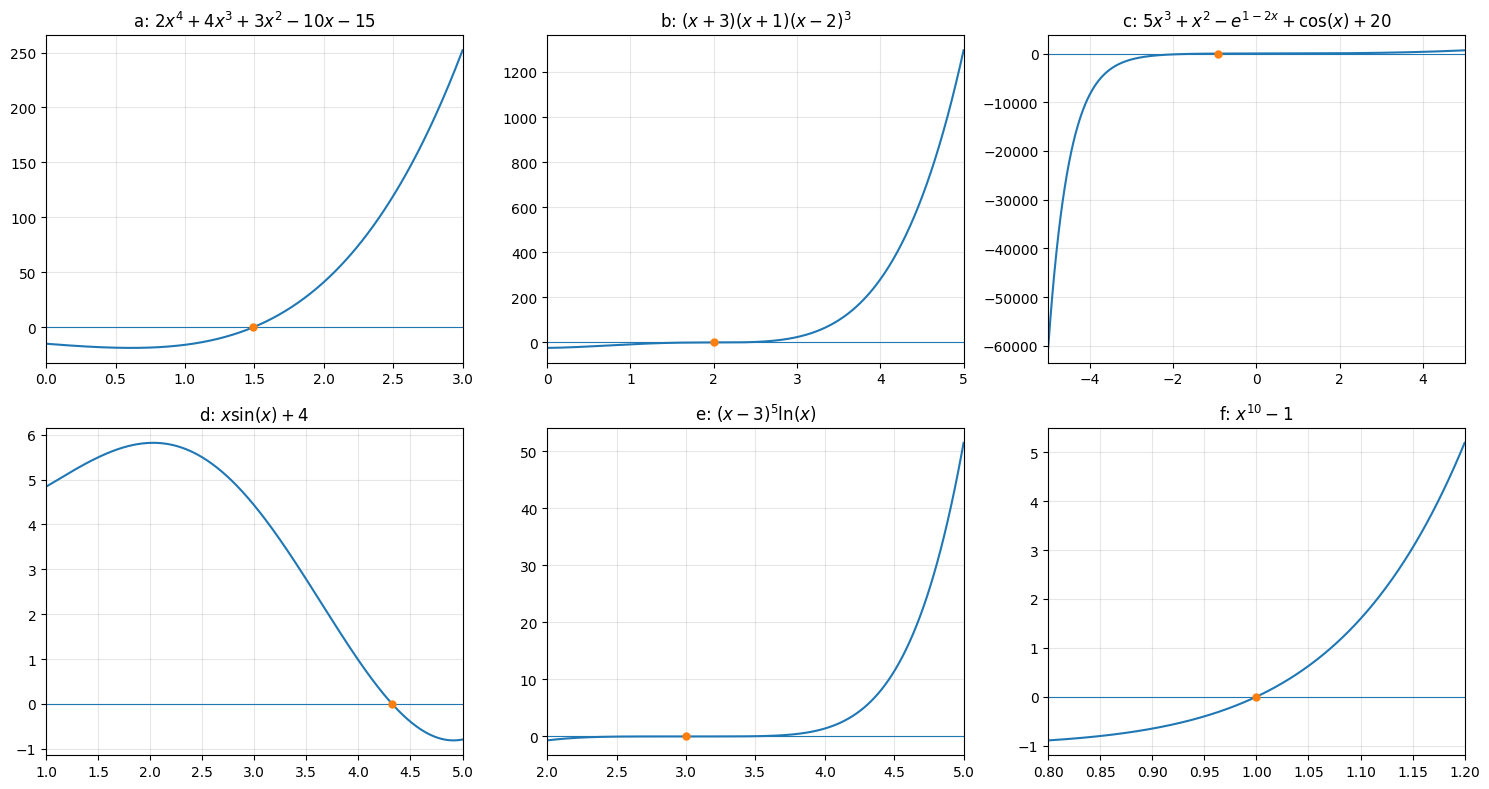

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, (k, d) in zip(axes, funcoes.items()):
    a, b = d["interval"]
    x = np.linspace(a, b, 600)
    y = d["f"](x)
    ax.plot(x, y)
    ax.axhline(0, linewidth=0.8)
    ax.plot(raizes_ref[k], 0, marker="o", markersize=5)
    ax.set_title(f"{k}: {d['equacao']}")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(a, b)

plt.tight_layout()
plt.show()

**Análise:** Os gráficos mostram a posição das raízes de referência em cada intervalo. As funções (b) e (e) apresentam raízes múltiplas, identificadas pelo cruzamento mais plano com o eixo horizontal; essa característica antecipa a maior dificuldade dos métodos iterativos nesses casos. A função (d) também merece atenção, pois métodos abertos podem sair do intervalo e convergir para outra raiz.

## 4. Avaliação dos métodos

A comparação principal segue a questão 4: bisseção, falsa posição e ponto fixo, acrescentando o gradiente descendente desenvolvido neste projeto. Newton-Raphson e secante aparecem como referências auxiliares para contextualizar o desempenho.

- Todos os métodos usam no máximo **200 iterações** e tolerância **\(10^{-10}\)**.
- Bisseção e falsa posição usam o intervalo da atividade.
- Ponto fixo, Newton e secante usam o limite direito do intervalo como estimativa inicial.
- O gradiente descendente é testado a partir de pontos internos e em múltiplos pontos para investigar raízes distintas.
- O critério de convergência é \(|f(x_k)|\leq 10^{-10}\); o erro absoluto em relação à referência é registrado separadamente.


In [5]:
def executar_comparacao(lr=0.1, objective="quadratic"):
    linhas = []
    for k, d in funcoes.items():
        f, fp = d["f"], d["fp"]
        a, b = d["interval"]
        testes = [
            ("Gradiente Descendente", lambda d=d: gradient_descent_root(
                d["f"], d["fp"], d["x0_open"], lr=lr, objective=objective,
                tol=TOL, max_iter=MAX_ITER, adaptive=True, max_step=1.0)),
            ("Bisseção", lambda d=d, a=a, b=b: scipy_bisection_root(
                d["f"], a, b, tol=TOL, max_iter=MAX_ITER)),
            ("Falsa Posição", lambda d=d, a=a, b=b: false_position_root(
                d["f"], a, b, tol=TOL, max_iter=MAX_ITER)),
            ("Ponto Fixo", lambda d=d: fixed_point_root(
                d["f"], d["g"], d["x0_open"], tol=TOL, max_iter=MAX_ITER)),
            ("Newton-Raphson", lambda d=d: newton_root(
                d["f"], d["fp"], d["x0_open"], tol=TOL, max_iter=MAX_ITER)),
            ("Secante", lambda d=d: secant_root(
                d["f"], d["x0_open"], d["x0_open"] - 0.25*(b-a),
                tol=TOL, max_iter=MAX_ITER)),
        ]
        for metodo, runner in testes:
            resultado = runner()
            root = resultado["root"]
            linhas.append({
                "funcao": k, "metodo": metodo, "raiz": root,
                "erro_abs": abs(root - raizes_ref[k]) if np.isfinite(root) else np.nan,
                "residuo": resultado.get("residual", np.nan),
                "iteracoes": resultado["iterations"],
                "convergiu": resultado["converged"],
                "chamadas_funcao": resultado.get("function_calls", np.nan),
                "chamadas_derivada": resultado.get("derivative_calls", np.nan),
                "backtracks": resultado.get("backtracks", np.nan),
                "objetivo": resultado.get("objective", "-"),
            })
    return pd.DataFrame(linhas)

df_cmp = executar_comparacao(lr=0.1, objective="quadratic")
df_cmp

,funcao,metodo,raiz,erro_abs,residuo,iteracoes,convergiu,chamadas_funcao,chamadas_derivada,backtracks,objetivo
0,a,Gradiente Descendente,1.492879,2.982503e-12,1.560370e-10,13,True,47,13,8.0,quadratic
1,a,Bisseção,1.492879,5.352541e-11,2.800384e-09,35,True,37,0,NaN,-
2,a,Falsa Posição,1.492879,1.764713e-10,9.232764e-09,65,True,67,0,NaN,-
3,a,Ponto Fixo,1.492879,6.019696e-11,3.149431e-09,36,True,72,0,NaN,-
4,a,Newton-Raphson,1.492879,0.000000e+00,1.776357e-15,7,True,14,14,NaN,-
5,a,Secante,1.492879,0.000000e+00,1.776357e-15,9,True,10,0,NaN,-
6,b,Gradiente Descendente,2.000000,3.552714e-15,0.000000e+00,4,True,12,4,0.0,quadratic
7,b,Bisseção,2.000000,4.365930e-11,1.248003e-30,36,True,38,0,NaN,-
8,b,Falsa Posição,1.714409,2.855909e-01,2.980818e-01,200,False,202,0,NaN,-
9,b,Ponto Fixo,2.346789,3.467888e-01,7.463054e-01,200,False,400,0,NaN,-


## 5. Arranjo de testes do gradiente descendente

Foram comparadas as taxas `0.001`, `0.01`, `0.05` e `0.1` com os objetivos \(J(f)=f^2/2\) (`quadratic`) e \(J(f)=\log(1+f^2)\) (`log_quadratic`). Cada configuração foi executada a partir de 21 pontos uniformemente distribuídos no intervalo. A escolha considera a maior taxa de convergência e, em empate, o menor número médio de iterações.


In [6]:
taxas = [0.001, 0.01, 0.05, 0.1]
objetivos = ["quadratic", "log_quadratic"]

def avaliar_configuracao_gd(lr, objective):
    linhas = []
    for k, d in funcoes.items():
        multistart = gradient_descent_multistart(
            d["f"], d["fp"], d["interval"], starts=21,
            lr=lr, objective=objective, tol=TOL, max_iter=MAX_ITER,
            adaptive=True, max_step=1.0
        )
        resultados = multistart["results"]
        validos = [r for r in resultados if r["converged"]]
        linhas.append({
            "funcao": k, "lr": lr, "objetivo": objective,
            "taxa_convergencia": len(validos) / len(resultados),
            "iteracoes_medias": np.mean([r["iterations"] for r in validos]) if validos else np.nan,
            "raizes_encontradas": len(multistart["roots"]),
        })
    return pd.DataFrame(linhas)


df_sweep = pd.concat(
    [avaliar_configuracao_gd(lr, objective) for lr in taxas for objective in objetivos],
    ignore_index=True
)

resumo_sweep = (
    df_sweep.groupby(["lr", "objetivo"], as_index=False)
    .agg(taxa_convergencia=("taxa_convergencia", "mean"),
         iteracoes_medias=("iteracoes_medias", "mean"),
         raizes_medias=("raizes_encontradas", "mean"))
    .sort_values(["taxa_convergencia", "iteracoes_medias"], ascending=[False, True])
)
resumo_sweep

melhor_configuracao = resumo_sweep.iloc[0].to_dict()
print("Melhor configuração:", melhor_configuracao)

Melhor configuração: {'lr': 0.1, 'objetivo': 'quadratic', 'taxa_convergencia': 0.6746031746031745, 'iteracoes_medias': 19.765873015873016, 'raizes_medias': 1.6666666666666667}


## 5.1 Exemplo explícito com múltiplas raízes

As seis funções da questão 4 são avaliadas no intervalo indicado e, em geral, o intervalo contém uma única raiz de interesse. Para demonstrar a capacidade de encontrar múltiplas raízes, usamos também

\[
h(x)=(x+2)(x-1)(x-3), \qquad x\in[-3,4],
\]

que possui as raízes \(-2\), \(1\) e \(3\). O gradiente descendente é iniciado em 61 pontos uniformes. As aproximações são agrupadas quando diferem menos que \(10^{-7}\).

In [7]:
h = lambda x: (x + 2)*(x - 1)*(x - 3)
hp = lambda x: 3*x**2 - 4*x - 5

multiplas_raizes = gradient_descent_multistart(
    h, hp, (-3.0, 4.0), starts=61,
    lr=0.01, objective="quadratic", tol=TOL,
    max_iter=MAX_ITER, adaptive=True, max_step=1.0
)

raizes_gd_multistart = pd.DataFrame({
    "raizes_encontradas": [multiplas_raizes["roots"]],
    "quantidade": [len(multiplas_raizes["roots"])],
    "raizes_exatas": [[-2.0, 1.0, 3.0]],
})
raizes_gd_multistart

,raizes_encontradas,quantidade,raizes_exatas
0,"[-2.0, 0.9999999998340554, 3.0]",3,"[-2.0, 1.0, 3.0]"


## 5.2 Sensibilidade do gradiente descendente ao ponto inicial

A Seção 4 usa `x0_open` (o limite do intervalo) para o gradiente descendente, exatamente como
para os demais métodos abertos — essa é a comparação "justa" e a que deve ser usada para tirar
conclusões sobre eficiência relativa entre métodos.

Nesta seção, comparamos explicitamente esse resultado com o que se obteria partindo de
`x0_favoravel`, um ponto interior mais próximo da raiz de referência (usado em uma versão
anterior deste notebook como ponto de partida "padrão" do GD). O objetivo é deixar visível o
quanto a escolha do ponto inicial afeta o resultado do método — algo que não fica claro quando
se olha só para a tabela final.

In [8]:
linhas_sensibilidade = []
for k, d in funcoes.items():
    for rotulo, x0 in [("x0_open (limite, comparação justa)", d["x0_open"]),
                       ("x0_favoravel (ponto interior)", d["x0_favoravel"])]:
        r = gradient_descent_root(d["f"], d["fp"], x0, lr=0.1, objective="quadratic",
                                   tol=TOL, max_iter=MAX_ITER, adaptive=True, max_step=1.0)
        linhas_sensibilidade.append({
            "funcao": k, "ponto_inicial": rotulo, "x0": x0,
            "raiz": r["root"], "erro_abs": abs(r["root"] - raizes_ref[k]),
            "iteracoes": r["iterations"], "convergiu": r["converged"],
        })

df_sensibilidade = pd.DataFrame(linhas_sensibilidade)
pd.set_option("display.float_format", lambda v: f"{v:.6g}")
df_sensibilidade

,funcao,ponto_inicial,x0,raiz,erro_abs,iteracoes,convergiu
0,a,"x0_open (limite, comparação justa)",3,1.49288,2.9825e-12,13,True
1,a,x0_favoravel (ponto interior),1.2,1.49288,2.33302e-12,11,True
2,b,"x0_open (limite, comparação justa)",5,2,3.55271e-15,4,True
3,b,x0_favoravel (ponto interior),2,2,3.55271e-15,1,True
4,c,"x0_open (limite, comparação justa)",5,-0.92956,3.58967e-11,68,True
5,c,x0_favoravel (ponto interior),-1,-0.92956,3.58967e-11,62,True
6,d,"x0_open (limite, comparação justa)",5,5.46131,1.13807,17,True
7,d,x0_favoravel (ponto interior),2.6,4.32324,3.0254e-11,24,True
8,e,"x0_open (limite, comparação justa)",5,3.00444,0.00443661,3,True
9,e,x0_favoravel (ponto interior),4,3.00444,0.00443661,2,True


**Análise:** nas funções (a), (b), (c) e (e) o resultado final é semelhante nas duas partidas
(o número de iterações muda, mas o GD converge para a raiz correta em ambos os casos). Nas
funções **(d)** e **(f)**, porém, o resultado muda de forma qualitativa:

- **(d)** `x sin(x) + 4`: partindo do limite `x0_open=5` (o mesmo ponto usado por Newton), o GD
  converge para a **mesma raiz espúria fora do intervalo** que o Newton encontra
  (`x≈5.4613`, fora de `[1,5]`). Ou seja, nessa função o GD **não é mais robusto que o Newton** —
  ele só parece robusto na Seção 4 de uma versão anterior porque partia de um ponto (2.6) já
  dentro da bacia de atração da raiz correta.
- **(f)** `x^10 - 1`: partindo do limite `x0_open=1.2` (o mesmo ponto usado pelos demais métodos
  abertos), o GD **não converge dentro de 200 iterações** — fica preso em uma região onde o
  gradiente é enorme (`f'(x)=10x^9` cresce muito rápido) e o backtracking reduz a taxa de
  aprendizagem até passos praticamente nulos, longe da raiz. Com o ponto favorável (`x0=0.9`),
  o mesmo método converge sem dificuldade em poucas iterações.

Essas duas funções deixam claro que o gradiente descendente, com essa implementação e sem
conhecimento prévio da localização da raiz, **não é intrinsecamente mais robusto que Newton ou
secante** à escolha do ponto inicial — a impressão de robustez que aparece quando se usa
`x0_favoravel` é, em boa parte, um artefato da escolha do ponto de partida, não uma propriedade
do método em si.

## 6. Tempo de execução com `%timeit`

No Jupyter, `%timeit` executa repetidamente uma operação e informa estatísticas do tempo. A comparação abaixo utiliza várias repetições para reduzir a influência de oscilações momentâneas do ambiente.

In [9]:

def tempo_repetido(func, number=100, repeat=5):
    tempos = timeit.repeat(func, number=number, repeat=repeat)
    return min(tempos) / number

metodos_comparacao = [
    "Gradiente Descendente", "Bisseção", "Falsa Posição",
    "Ponto Fixo", "Newton-Raphson", "Secante"
]
tempo_linhas = []

for k, d in funcoes.items():
    a, b = d["interval"]
    jobs = {
        "Gradiente Descendente": lambda d=d: gradient_descent_root(
            d["f"], d["fp"], d["x0_open"], lr=0.1, objective="quadratic",
            tol=TOL, max_iter=MAX_ITER, adaptive=True, max_step=1.0),
        "Bisseção": lambda d=d, a=a, b=b: scipy_bisection_root(
            d["f"], a, b, tol=TOL, max_iter=MAX_ITER),
        "Falsa Posição": lambda d=d, a=a, b=b: false_position_root(
            d["f"], a, b, tol=TOL, max_iter=MAX_ITER),
        "Ponto Fixo": lambda d=d: fixed_point_root(
            d["f"], d["g"], d["x0_open"], tol=TOL, max_iter=MAX_ITER),
        "Newton-Raphson": lambda d=d: newton_root(
            d["f"], d["fp"], d["x0_open"], tol=TOL, max_iter=MAX_ITER),
        "Secante": lambda d=d, a=a, b=b: secant_root(
            d["f"], d["x0_open"], d["x0_open"] - 0.25*(b-a),
            tol=TOL, max_iter=MAX_ITER),
    }
    for metodo, job in jobs.items():
        tempo_linhas.append({
            "funcao": k, "metodo": metodo,
            "tempo_ms": 1e3 * tempo_repetido(job)
        })

df_tempo = pd.DataFrame(tempo_linhas)
df_resultados = df_cmp.merge(df_tempo, on=["funcao", "metodo"], how="left")
df_resultados.sort_values(["funcao", "metodo"]).reset_index(drop=True)

,funcao,metodo,raiz,erro_abs,residuo,iteracoes,convergiu,chamadas_funcao,chamadas_derivada,backtracks,objetivo,tempo_ms
0,a,Bisseção,1.49288,5.35254e-11,2.80038e-09,35,True,37,0,NaN,-,0.049344
1,a,Falsa Posição,1.49288,1.76471e-10,9.23276e-09,65,True,67,0,NaN,-,0.0260194
2,a,Gradiente Descendente,1.49288,2.9825e-12,1.56037e-10,13,True,47,13,8,quadratic,0.164571
3,a,Newton-Raphson,1.49288,0,1.77636e-15,7,True,14,14,NaN,-,0.127919
4,a,Ponto Fixo,1.49288,6.0197e-11,3.14943e-09,36,True,72,0,NaN,-,0.0468253
5,a,Secante,1.49288,0,1.77636e-15,9,True,10,0,NaN,-,0.158077
6,b,Bisseção,2,4.36593e-11,1.248e-30,36,True,38,0,NaN,-,0.0429087
7,b,Falsa Posição,1.71441,0.285591,0.298082,200,False,202,0,NaN,-,0.0555574
8,b,Gradiente Descendente,2,3.55271e-15,0,4,True,12,4,0,quadratic,0.0351259
9,b,Newton-Raphson,2,1.40054e-10,4.12047e-29,60,True,120,120,NaN,-,0.927011


## 7. Tabela final

`erro_abs` é o erro absoluto entre a aproximação retornada pelo método e a raiz de referência. A coluna `convergiu` indica se o critério numérico adotado foi satisfeito dentro do limite de 200 iterações.

In [10]:
df_final = df_resultados.copy()

for column in ["raiz", "erro_abs", "residuo", "tempo_ms"]:
    if column in df_final:
        df_final[column] = df_final[column].map(
            lambda value: f"{value:.6g}" if pd.notna(value) else "-"
        )

df_final[
    ["funcao", "metodo", "raiz", "erro_abs", "residuo",
     "iteracoes", "convergiu", "tempo_ms", "chamadas_funcao",
     "chamadas_derivada", "backtracks"]
]

,funcao,metodo,raiz,erro_abs,residuo,iteracoes,convergiu,tempo_ms,chamadas_funcao,chamadas_derivada,backtracks
0,a,Gradiente Descendente,1.49288,2.9825e-12,1.56037e-10,13,True,0.164571,47,13,8
1,a,Bisseção,1.49288,5.35254e-11,2.80038e-09,35,True,0.049344,37,0,NaN
2,a,Falsa Posição,1.49288,1.76471e-10,9.23276e-09,65,True,0.0260194,67,0,NaN
3,a,Ponto Fixo,1.49288,6.0197e-11,3.14943e-09,36,True,0.0468253,72,0,NaN
4,a,Newton-Raphson,1.49288,0,1.77636e-15,7,True,0.127919,14,14,NaN
5,a,Secante,1.49288,0,1.77636e-15,9,True,0.158077,10,0,NaN
6,b,Gradiente Descendente,2,3.55271e-15,0,4,True,0.0351259,12,4,0
7,b,Bisseção,2,4.36593e-11,1.248e-30,36,True,0.0429087,38,0,NaN
8,b,Falsa Posição,1.71441,0.285591,0.298082,200,False,0.0555574,202,0,NaN
9,b,Ponto Fixo,2.34679,0.346789,0.746305,200,False,0.200442,400,0,NaN


## 8. Visualizações comparativas

Os gráficos a seguir complementam a tabela final. A ordem de apresentação é: iterações, tempo, erro absoluto, trajetória do gradiente descendente e taxa de convergência.

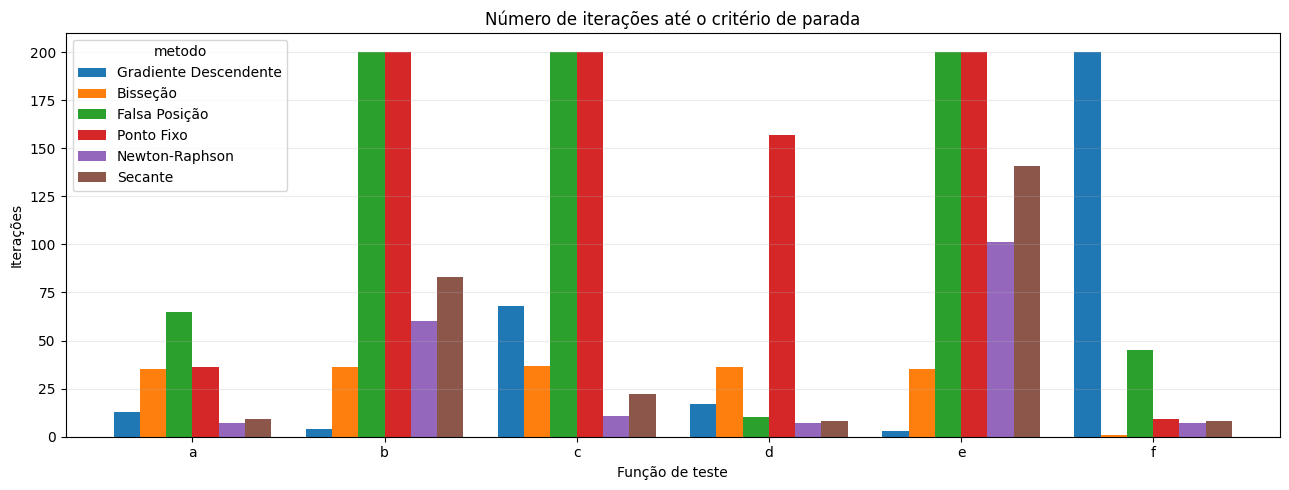

In [11]:
metodos_ordem = [
    'Gradiente Descendente', 'Bisseção', 'Falsa Posição',
    'Ponto Fixo', 'Newton-Raphson', 'Secante'
]
pivot_iter = df_resultados.pivot(index='funcao', columns='metodo', values='iteracoes')
pivot_iter = pivot_iter.reindex(columns=metodos_ordem)

ax = pivot_iter.plot(kind='bar', figsize=(13, 5), width=0.82)
ax.set_title('Número de iterações até o critério de parada')
ax.set_xlabel('Função de teste')
ax.set_ylabel('Iterações')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


**Análise:** O gráfico evidencia o custo iterativo de cada método. Newton e secante tendem a usar menos iterações nas raízes simples, enquanto bisseção mantém um comportamento mais regular. O gradiente descendente apresenta custo intermediário e o ponto fixo pode exigir muitas iterações, especialmente quando a função é plana próxima da raiz.

### Iterações em escala logarítmica

Esta versão é útil quando há diferenças grandes entre os métodos, sem ocultar os casos de convergência lenta.


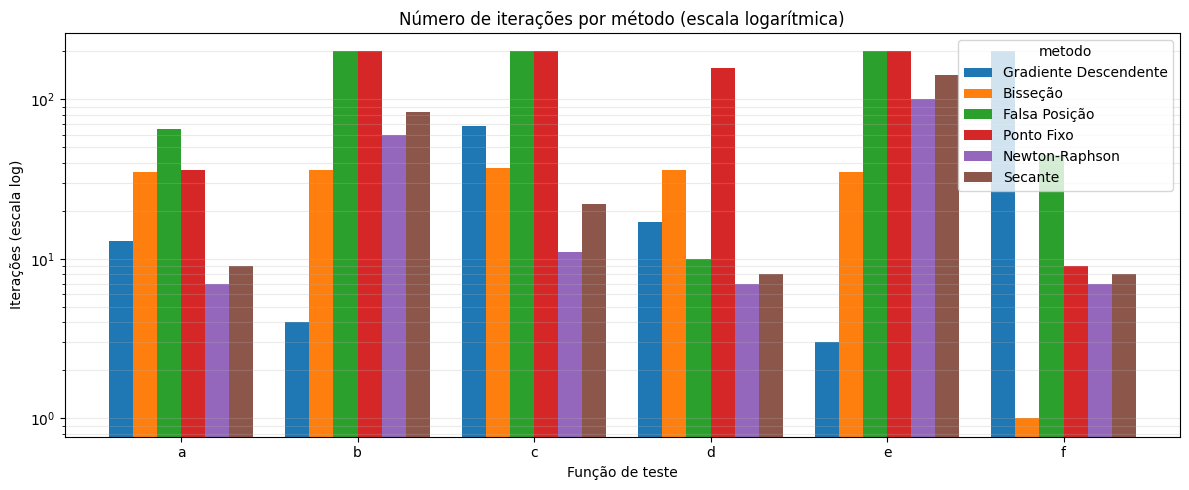

In [12]:
ax = pivot_iter.plot(kind='bar', figsize=(12, 5), width=0.82, logy=True)
ax.set_title('Número de iterações por método (escala logarítmica)')
ax.set_xlabel('Função de teste')
ax.set_ylabel('Iterações (escala log)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.25, which='both')
plt.tight_layout()
plt.show()


**Análise:** A escala logarítmica torna visíveis as diferenças entre métodos que ficam comprimidas no gráfico linear. Os casos que atingem o limite de 200 iterações aparecem destacados, indicando estagnação ou convergência insuficiente. Essa leitura é particularmente importante para falsa posição e ponto fixo nas funções com raízes múltiplas.

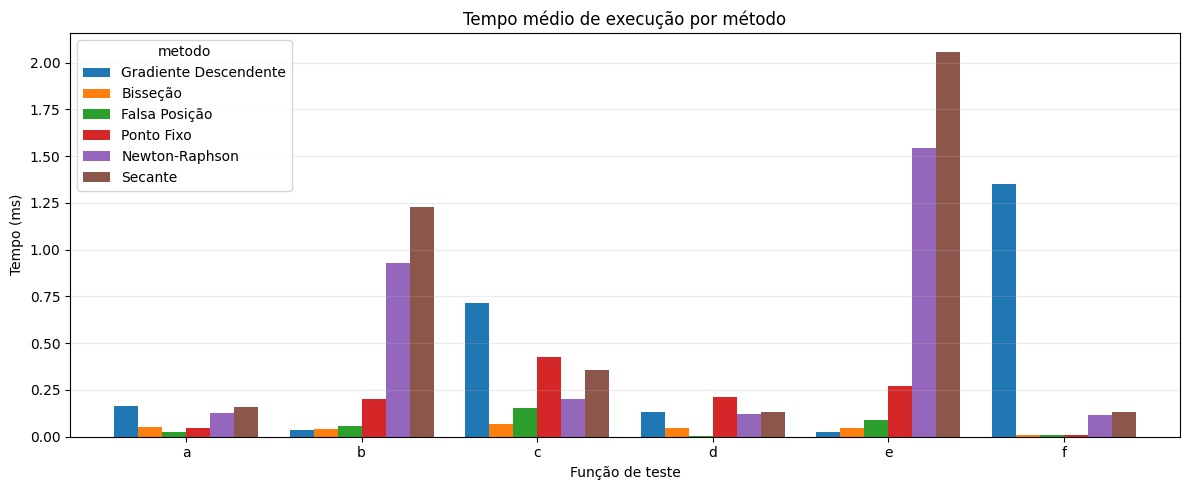

In [13]:
pivot_tempo = df_resultados.pivot(index='funcao', columns='metodo', values='tempo_ms')
pivot_tempo = pivot_tempo.reindex(columns=metodos_ordem)

ax = pivot_tempo.plot(kind='bar', figsize=(12, 5), width=0.82)
ax.set_title('Tempo médio de execução por método')
ax.set_xlabel('Função de teste')
ax.set_ylabel('Tempo (ms)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


**Análise:** O tempo de execução acompanha, em geral, o número de avaliações da função e da derivada. O gradiente descendente pode ser mais caro por causa do backtracking, que testa pontos adicionais. Esses valores são comparáveis apenas dentro do mesmo ambiente; por isso, o número de iterações e de chamadas também deve ser considerado.

### Erro absoluto da raiz

O erro absoluto compara diretamente a aproximação encontrada com a raiz de referência. Para visualizar diferenças muito pequenas, usamos escala logarítmica no eixo vertical.


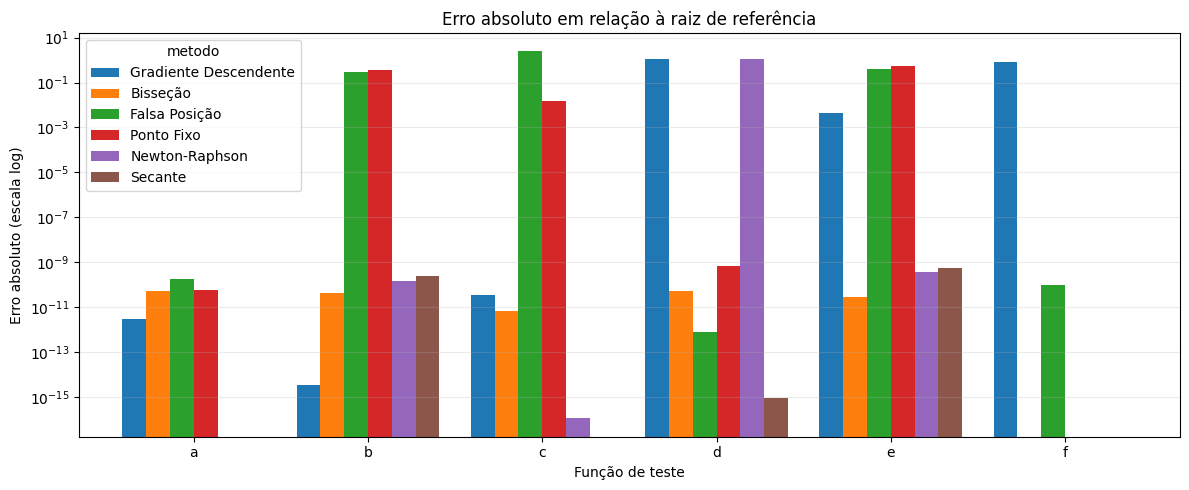

In [14]:
pivot_erro = df_resultados.pivot(index='funcao', columns='metodo', values='erro_abs')
pivot_erro = pivot_erro.reindex(columns=metodos_ordem)
pivot_erro = pivot_erro.replace(0, np.nan)

ax = pivot_erro.plot(kind='bar', figsize=(12, 5), width=0.82, logy=True)
ax.set_title('Erro absoluto em relação à raiz de referência')
ax.set_xlabel('Função de teste')
ax.set_ylabel('Erro absoluto (escala log)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.25, which='both')
plt.tight_layout()
plt.show()


**Análise:** O erro absoluto permite verificar se a aproximação está próxima da raiz de referência, enquanto o resíduo sozinho pode ser enganoso. Nas funções (b) e (e), as raízes múltiplas produzem regiões planas: alguns métodos atingem resíduo pequeno sem apresentar erro igualmente pequeno em `x`. A ausência de barra indica erro nulo ou valor não disponível na escala logarítmica.

### Convergência do gradiente descendente

Os gráficos seguintes mostram a evolução de \(|f(x_k)|\) ao longo das iterações do gradiente descendente. Isso permite observar não apenas quantas iterações foram necessárias, mas também como ocorre a aproximação da raiz.


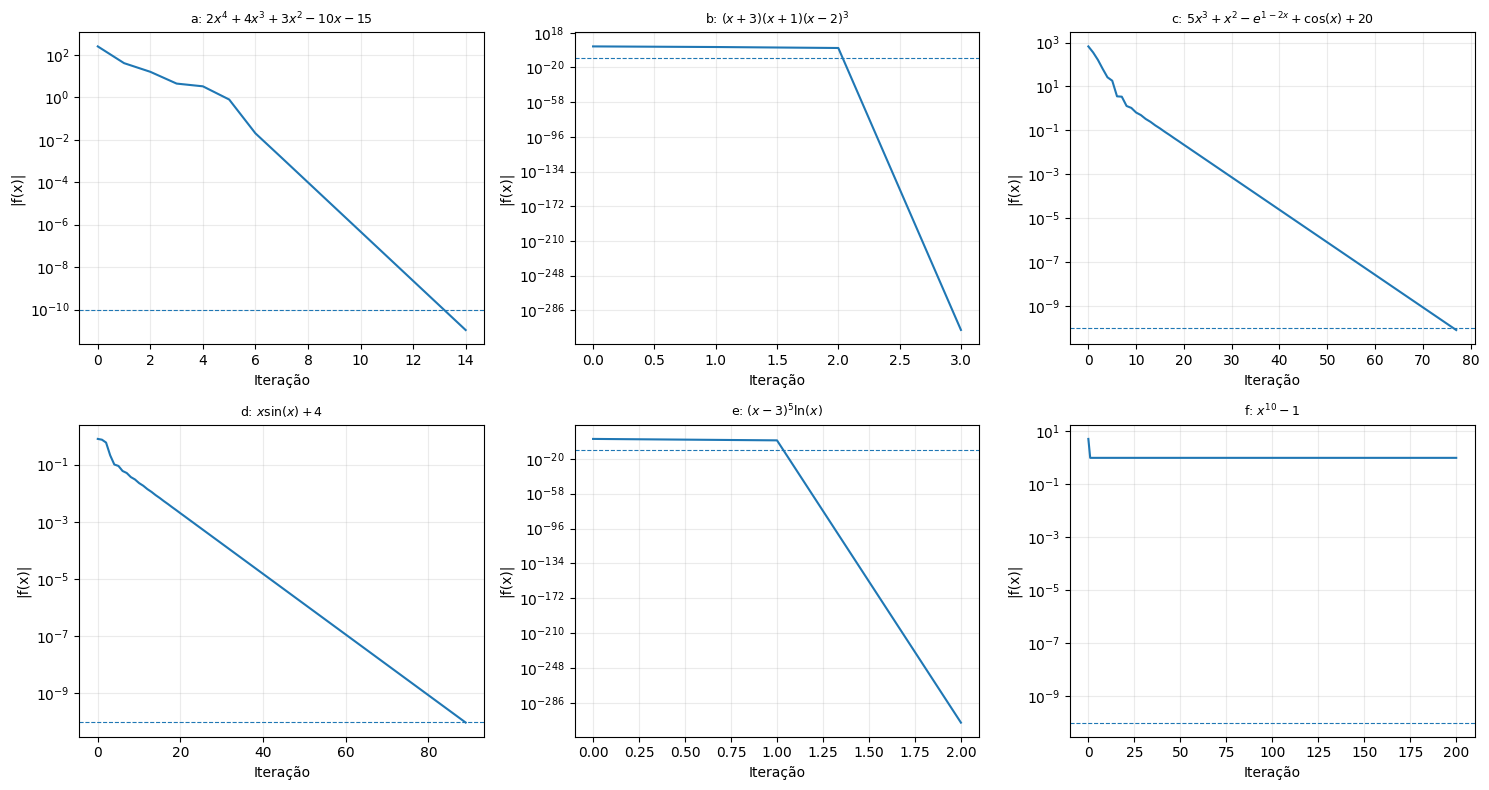

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, (k, d) in zip(axes, funcoes.items()):
    res = gradient_descent_root(
        d['f'], d['fp'], d['x0_open'], lr=0.1, tol=TOL,
        max_iter=MAX_ITER, adaptive=True, max_step=1.0
    )
    x = float(d['x0_open'])
    erros = []
    for _ in range(MAX_ITER + 1):
        erros.append(abs(float(d['f'](x))))
        fx = float(d['f'](x))
        dfx = float(d['fp'](x))
        if not np.isfinite(fx) or not np.isfinite(dfx):
            break
        dJ = 2.0 * fx * dfx
        step = np.clip(0.1 * dJ, -1.0, 1.0)
        x_new = x - step
        J = fx**2
        J_new = float(d['f'](x_new))**2
        lr_local = 0.1
        bt = 0
        while (not np.isfinite(J_new) or J_new > J) and lr_local > 1e-12 and bt < 40:
            lr_local *= 0.5
            step = np.clip(lr_local * dJ, -1.0, 1.0)
            x_new = x - step
            J_new = float(d['f'](x_new))**2
            bt += 1
        if abs(x_new - x) <= TOL:
            erros.append(abs(float(d['f'](x_new))))
            break
        x = x_new

    valores = np.maximum(erros, np.finfo(float).tiny)
    ax.semilogy(range(len(valores)), valores)
    ax.axhline(TOL, linewidth=0.8, linestyle='--')
    ax.set_title(f'{k}: {d["equacao"]}', fontsize=9)
    ax.set_xlabel('Iteração')
    ax.set_ylabel('|f(x)|')
    ax.grid(True, alpha=0.25, which='both')

plt.tight_layout()
plt.show()


**Análise:** As curvas mostram a redução de `|f(x)|` durante as iterações do gradiente descendente. Quedas rápidas indicam uma região favorável e backtracking reduzido; trechos longos ou quase horizontais indicam passos pequenos ou uma função plana. A linha tracejada representa o critério de parada `1e-10`.

### Resumo visual da convergência

Além das curvas, a taxa de convergência mostra quantas execuções atingiram o critério \(|x_{k+1}-x_k|\le10^{-10}\) dentro do limite de 200 iterações.


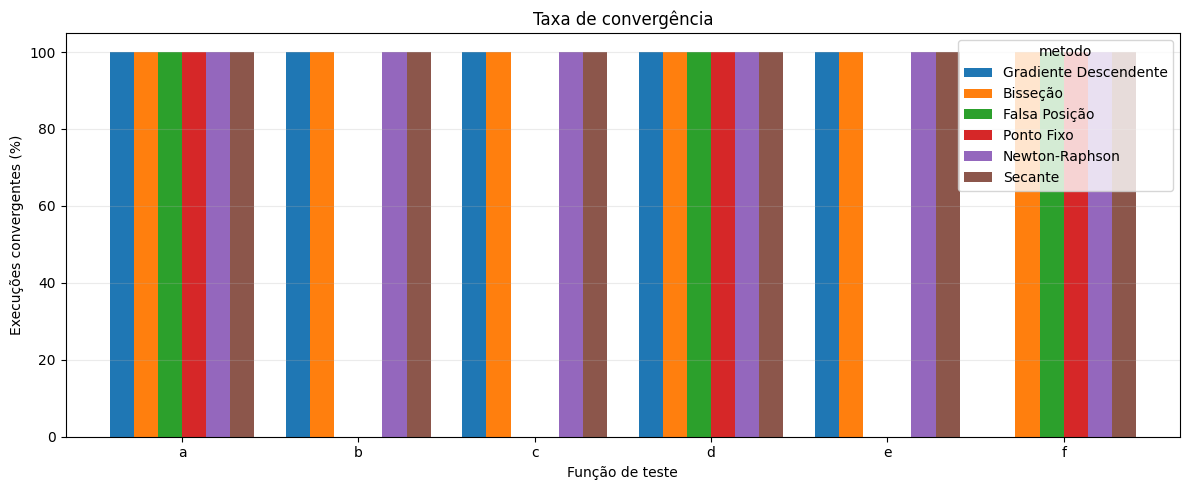

In [16]:
taxa_conv = (df_resultados.groupby(['funcao', 'metodo'])['convergiu']
             .mean().unstack('metodo').reindex(columns=metodos_ordem))

ax = taxa_conv.mul(100).plot(kind='bar', figsize=(12, 5), width=0.82)
ax.set_title('Taxa de convergência')
ax.set_xlabel('Função de teste')
ax.set_ylabel('Execuções convergentes (%)')
ax.set_ylim(0, 105)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


**Análise:** A taxa de convergência resume a robustez de cada método para as funções avaliadas. O gradiente descendente depende da taxa de aprendizagem, do objetivo e da inicialização; os demais métodos refletem principalmente a estrutura da função e os pontos iniciais adotados. Valores abaixo de 100% mostram que o método não atingiu o critério de parada em todas as execuções dentro de 200 iterações.

## 9. Discussão técnica

### Bisseção

A bisseção é um método fechado: começa com \(f(a)f(b)<0\), calcula o ponto médio e conserva o subintervalo que ainda contém a mudança de sinal. Sua convergência é garantida para uma função contínua com raiz isolada no intervalo e é linear. Por isso, é previsível, porém costuma exigir mais iterações.

### Falsa posição

A falsa posição conserva o intervalo e a troca de sinal da bisseção, mas calcula a interseção da secante com o eixo:

\[
x=\frac{a f(b)-b f(a)}{f(b)-f(a)}.
\]

Ela pode ser mais rápida quando a função é aproximadamente linear em parte do intervalo. Em contrapartida, uma extremidade pode permanecer fixa por muitas iterações, principalmente em funções assimétricas ou com raízes múltiplas.

### Ponto fixo

O método transforma \(f(x)=0\) em \(x=g(x)\) e repete \(x_{k+1}=g(x_k)\). A convergência local depende de \(|g'(x^*)|<1\). Foram usadas reformulações amortecidas \(g(x)=x-\lambda f(x)\). A escolha de \(g\) é determinante: diferentes reformulações da mesma equação podem convergir para raízes diferentes, convergir lentamente ou divergir.

Nas funções (b) e (e), a raiz de interesse é múltipla. Como a função fica plana na raiz, a iteração simples não atingiu o resíduo exigido em 200 passos. Essa não convergência é um resultado do condicionamento do problema e da reformulação escolhida.

### Gradiente descendente

Para buscar raízes, minimiza-se um objetivo não negativo que atinge o mínimo quando \(f(x)=0\). No objetivo quadrático,

\[
J(x)=\frac{1}{2}f(x)^2,
\qquad
x_{k+1}=x_k-\alpha f(x_k)f'(x_k).
\]

Também foi testado \(J(x)=\log(1+f(x)^2)\), cujo gradiente é \(2f(x)f'(x)/(1+f(x)^2)\). O backtracking reduz a taxa quando o novo ponto aumenta o objetivo. O multistart executa o método a partir de vários pontos e agrupa aproximações próximas, permitindo localizar raízes em bacias de atração distintas.

A varredura selecionou \(\alpha=0.1\) e o objetivo quadrático pela maior taxa média de convergência. Na comparação principal (Seção 4), o GD parte do **mesmo limite do intervalo** usado pelos demais métodos abertos, e os resultados mostram que ele **não é uniformemente mais robusto** que Newton ou secante: na função (d) ele converge para a mesma raiz espúria fora do intervalo que o Newton encontra, e na função (f) ele sequer converge dentro de 200 iterações a partir desse ponto (Seção 5.2 mostra essa sensibilidade de forma explícita, comparando lado a lado o ponto do enunciado com um ponto interior mais favorável). Onde ele efetivamente se destaca é na busca de **múltiplas raízes**: o exemplo \(h(x)=(x+2)(x-1)(x-3)\) confirmou a recuperação das três raízes conhecidas a partir de um único conjunto de execuções (multistart), algo que os demais métodos abertos não fazem nativamente — cada um encontra, no máximo, uma raiz por execução, condicionada à escolha do ponto (ou intervalo) inicial.

### Newton-Raphson e secante

Newton usa

\[
x_{k+1}=x_k-\frac{f(x_k)}{f'(x_k)}.
\]

Perto de uma raiz simples e com inicialização adequada, apresenta convergência quadrática. Entretanto, uma inicialização ruim pode produzir saltos ou convergir para outra raiz. Na função (d), o ponto inicial no limite direito levou a uma raiz fora do intervalo de interesse, apesar do resíduo pequeno.

A secante substitui a derivada pela inclinação entre dois pontos. Ela costuma ser rápida e não requer derivada analítica, mas depende das estimativas iniciais.

### Interpretação conjunta

`convergiu` indica o atendimento do critério de parada \(|x_{k+1}-x_k|\leq10^{-10}\). O resíduo é reportado separadamente para avaliar a qualidade da aproximação. (ver função (e) na Seção 4: sem esse ajuste, o GD "convergia" em 1 iteração com erro de \(x\) da ordem de \(10^{-3}\)). `erro_abs` mede a distância até a referência independente, `iteracoes` mede o custo algorítmico e `tempo_ms` depende do ambiente de execução. Ainda assim, nas raízes múltiplas o resíduo continua valendo a pena observar separadamente (coluna `residuo`), pois ilustra por que o critério em \(x\) é necessário: perto de \((x-3)^5\) ou \((x-2)^3\), pequenas variações em \(x\) já produzem resíduos muito pequenos, e vice-versa.


## 10. Conclusão

O experimento mostrou que não existe um método dominante para todas as funções. A bisseção é a opção mais previsível quando há mudança de sinal; a falsa posição pode ser eficiente em funções assimétricas, mas trava quando uma extremidade do intervalo fica praticamente fixa; o ponto fixo depende inteiramente de uma reformulação contrativa (e falha nas duas raízes múltiplas testadas); Newton e secante são os mais rápidos perto de raízes simples, mas sensíveis à inicialização, podendo convergir para uma raiz fora do intervalo de interesse (função (d)).

O gradiente descendente, quando testado sob a **mesma regra de inicialização exigida dos demais métodos abertos** (partir do limite do intervalo), não se mostrou mais robusto que Newton ou secante: falhou exatamente nas mesmas duas funções em que Newton tem dificuldade ((d), convergindo para a raiz espúria) ou pior ((f), sem convergir em 200 iterações). Sua vantagem real e específica é a **busca de múltiplas raízes via multistart**, demonstrada com \(h(x)=(x+2)(x-1)(x-3)\) — uma capacidade que nenhum dos outros métodos testados oferece nativamente em uma única configuração.

As funções (b) e (e) evidenciaram o efeito de raízes múltiplas: a função fica plana perto da raiz, a convergência se torna mais lenta (ou falha, no caso do ponto fixo) e o resíduo isoladamente deixa de ser um indicador suficiente do erro na variável — por isso o critério de parada adotado aqui é sobre \(\Delta x\), e o resíduo é reportado apenas como diagnóstico complementar. A avaliação deve, portanto, considerar simultaneamente resíduo, erro absoluto, iterações, convergência, tempo — e, no caso de métodos abertos, também a sensibilidade ao ponto inicial escolhido, que pode ser tão determinante para o resultado quanto o método em si.